# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

С Ollama на CPU запукать сотни прогонов больно. Free tiers отлетают по rate limits. Пробовал поработать через colab kernel с GPU, но это оказалось ещё больнее в плане совместимости пакетов и настройки инференса. Так что мой выбор - openrouter. (И с ним тоже оказалось очень больно, но в конце концов получилось всё настроить) 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [32]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

# MODEL_A = "ollama/llama2"        # weaker / baseline model
# MODEL_B = "ollama/qwen2:latest"  # stronger / comparison model

In [ ]:
import os
os.environ['OPENROUTER_API_KEY'] = '' 

In [3]:
MODEL_A = "openrouter/meta-llama/llama-3.2-3b-instruct"
MODEL_B = "openrouter/google/gemma-2-9b-it"

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [4]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [5]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [6]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "econometrics"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 114 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [7]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [9]:
logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    limit=10,
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : openrouter/meta-llama/llama-3.2-3b-instruct
Accuracy: 0.4


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [10]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []

    for sample in log.samples:
        score_obj = next(iter(sample.scores.values()))
        score_value = score_obj.value

        rows.append({
            "id": sample.id,
            "epoch": sample.epoch if sample.epoch is not None else 0,
            "score": 1 if score_value == "C" else 0,
            "subject": sample.metadata.get("subject")
        })

    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score       subject
0   1      1      1  econometrics
1   2      1      0  econometrics
2   3      1      1  econometrics
3   4      1      0  econometrics
4   5      1      0  econometrics

Accuracy: 40.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [11]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).
    """
    scores = np.asarray(scores, dtype=float)
    n = len(scores)
    mean_acc = scores.mean()

    z = stats.norm.ppf(0.5 + ci / 2)
    se = np.sqrt(mean_acc * (1 - mean_acc) / n)
    margin = z * se

    lower = max(0.0, mean_acc - margin)
    upper = min(1.0, mean_acc + margin)

    return lower, mean_acc, upper


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).
    """
    
    counts = df.groupby("id")["epoch"].nunique()

    if (counts == 1).all():
        return ci_accuracy_basic(df["score"].to_numpy(), ci=ci)

    q_scores = df.groupby("id")["score"].mean().to_numpy()

    n = len(q_scores)
    mean_acc = q_scores.mean()

    z = stats.norm.ppf(0.5 + ci / 2)
    se = q_scores.std(ddof=1) / np.sqrt(n)
    margin = z * se

    lower = max(0.0, mean_acc - margin)
    upper = min(1.0, mean_acc + margin)

    return lower, mean_acc, upper

In [12]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.227  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

K=2: started
Expected rows: 228


K=2: eval ended


Output()

K=2: ended in 53.4s, status=success, rows=228
K=3: started
Expected rows: 342


...

Output()

K=9: ended in 268.9s, status=success, rows=1026
K=10: started
Expected rows: 1140


+-------------------------------------- Traceback (most recent call last) ---------------------------------------+
| D:\AI_Safety_and_Evals_Course\.venv\Lib\site-packages\inspect_ai\model\_model.py:977 in generate               |
+----------------------------------------------------------------------------------------------------------------+
AttemptTimeoutError: attempt_timeout '120' exceeded.

+-------------------------------------- Traceback (most recent call last) ---------------------------------------+
| D:\AI_Safety_and_Evals_Course\.venv\Lib\site-packages\inspect_ai\model\_model.py:977 in generate               |
+----------------------------------------------------------------------------------------------------------------+
AttemptTimeoutError: attempt_timeout '120' exceeded.

K=10: eval ended
K=10: ended in 306.0s, status=success, rows=1140


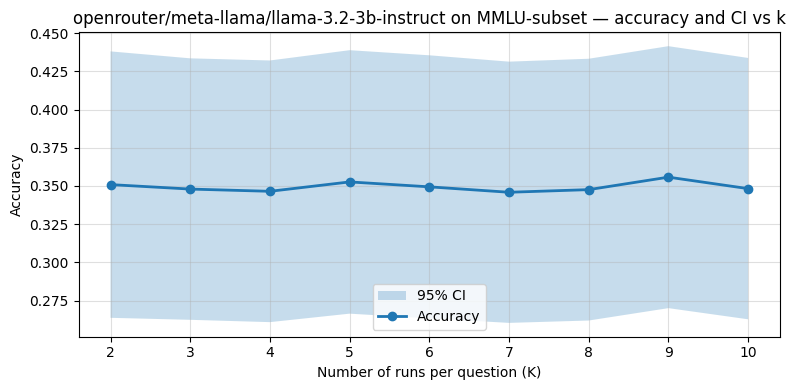

In [17]:
from time import perf_counter

k_values   = [2, 3, 4, 5, 6, 7, 8, 9, 10]
accuracies = []
ci_lowers  = []
ci_uppers  = []

for k in k_values:

    print(f"K={k}: started")
    print(f'Expected rows: {114 * k}')
    t0 = perf_counter()
    
    logs_k: List[EvalLog] = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
        epochs=k,

        max_connections=3,
        max_samples=3,
        max_retries=4,
        attempt_timeout=120,
        timeout=300,

        # диагностика
        debug_errors=True,
        log_model_api=True,
    )
    print(f"K={k}: eval ended")
    t1 = perf_counter()
    log_k = logs_k[0]
    df_k = log_to_df(log_k)

    l, m, u = ci_accuracy(df_k, ci=0.95)

    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)

    print(f"K={k}: ended in {t1 - t0:.1f}s, status={log_k.status}, rows={len(df_k)}")

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?  
3. Does more K change your estimate of the model's accuracy, or just your confidence in it?
4. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. В нашем случае (на конкретном сабсемпле MMLU, с конретной моделью) сужения доверительных интервалов при росте числа семплов не происходит в принципе. Получается внутривопросная вариация достаточно мала и повторное семплирование не дает никакого выигрыша.
2. Увеличение K не должно изменять саму оценку accuracy, если наш дизайн уже позволяет считать её несмещённой. Сужаться должны доверительные интервалы, за счет снижения внутривопросной вариации. Это повышает нашу уверенность в оценке. 
3. В нашем случае тратить бюджет на семплирование выходит нецелесообразно. Лучше, если есть такая возможность, увеличить пул вопросов

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

In [18]:
df_k

,id,epoch,score,subject
0,1,1,1,econometrics
1,2,1,0,econometrics
2,3,1,1,econometrics
3,4,1,0,econometrics
4,5,1,0,econometrics
...,...,...,...,...
1135,110,10,0,econometrics
1136,111,10,1,econometrics
1137,112,10,0,econometrics
1138,113,10,1,econometrics


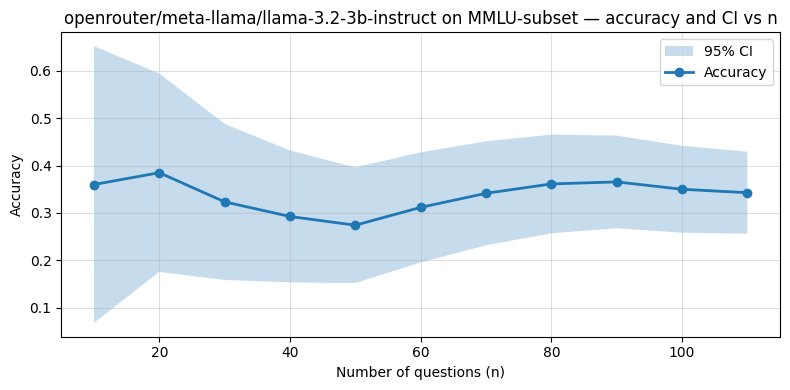

In [19]:
question_ids = sorted(df_k["id"].unique())
dataset_sizes = list(range(10, len(question_ids) + 1, 10))

accuracies = []
ci_lowers = []
ci_uppers = []
ci_widths = []

for n in dataset_sizes:
    keep_ids = question_ids[:n]
    df_slice = df_k[df_k["id"].isin(keep_ids)].copy()

    l, m, u = ci_accuracy(df_slice, ci=0.95)

    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)
    ci_widths.append(u - l)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

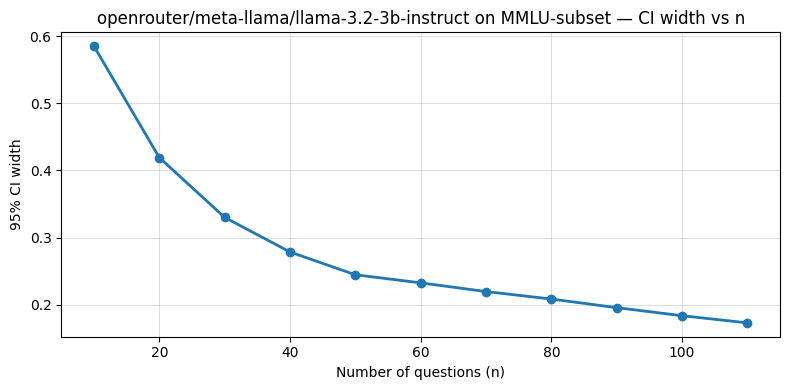

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(dataset_sizes, ci_widths, "o-", lw=2)
plt.xlabel("Number of questions (n)")
plt.ylabel("95% CI width")
plt.title(f"{MODEL_A} on MMLU-subset — CI width vs n")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**
1. Порядка 70-80 вопросов.
2. Похоже что да, у 114 вопросам accuracy более-менее стабилизируется.
3. Увеличение числа вопросов реально позволяет снизить вариацию, поскольку в нашем случае именно межвопросная вариация играет основную роль

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [25]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"

    scores1 = np.asarray(scores1, dtype=float)
    scores2 = np.asarray(scores2, dtype=float)
    diffs = scores1 - scores2
    mean_diff   = float(np.mean(diffs))

    _, p_value  = stats.ttest_rel(scores1, scores2, alternative=alternative)
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [25]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


D:\AI_Safety_and_Evals_Course\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [26]:
p_value, mean_diff, is_significant = compare_models_paired(
    model_a=MODEL_A,
    model_b=MODEL_B,
    dataset=MY_SUBSET,
    alpha=0.05,
    two_tailed=True,   # проверяем, есть ли отличие вообще
    epochs_a=1, # поскольку видели, что увеличение K не сужает CIs
    epochs_b=1, #
)

print(f"p-value: {p_value:.6f}")
print(f"mean difference (A - B): {mean_diff:.6f}")
print(f"significant at alpha=0.05: {is_significant}")

Output()

  Running openrouter/meta-llama/llama-3.2-3b-instruct ...


Output()

  Running openrouter/google/gemma-2-9b-it ...


p-value: 0.085835
mean difference (A - B): -0.096491
significant at alpha=0.05: False


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

1. P-value $\approx$ 0.086. Средняя разница (А - B) $\approx$ -0.096.
2. Гэп не значим на 5%-м уровне значимости. Правда, является значимым на 10%. При этом сама величина разрыва около 9.6 п.п. выглядит практически небессмысленной, но статистической уверенности на стандартном уровне 5% нам пока не хватает.
3. Большее число вопросов может повысить мощность теста и изменить вывод о значимости. Другой subset может дать другие результаты, так как разрыв может зависеть от предметной области. Другая пара моделей тоже может показать иной эффект, что естественным образом изменит выводы.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [30]:
def ci_accuracy_for_difference(
    scores1: np.ndarray,
    scores2: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Confidence interval for the mean paired difference scores1 - scores2.
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    scores1 = np.asarray(scores1, dtype=float)
    scores2 = np.asarray(scores2, dtype=float)

    diffs = scores1 - scores2
    n = len(diffs)
    mean_diff = diffs.mean()

    if n < 2:
        return mean_diff, mean_diff, mean_diff

    sd = diffs.std(ddof=1)
    se = sd / np.sqrt(n)

    t_crit = stats.t.ppf(0.5 + ci / 2, df=n - 1)
    margin = t_crit * se

    lower = mean_diff - margin
    upper = mean_diff + margin

    return lower, mean_diff, upper

In [32]:
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET, epochs=1)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET, epochs=1)

l, m, u = ci_accuracy_for_difference(scores_a, scores_b, ci=0.95)

print(f"95% CI for (A - B): [{l:.6f}, {u:.6f}]")
print(f"mean difference (A - B): {m:.6f}")

  Running openrouter/meta-llama/llama-3.2-3b-instruct ...


Output()

  Running openrouter/google/gemma-2-9b-it ...


Output()

95% CI for (A - B): [-0.195114, 0.037220]
mean difference (A - B): -0.078947


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

1. 95% Доверительный интервал для разности оценок [-0.195114, 0.037220]. Как и ожидалось, он содержит 0.
2. Это согласуется выводами о значимости из задания 5. Они tell the same story, потому что это эквивалентные способы говорить о значимости различий. Если 0 входит в 95%-й ДИ, то различия не значимы, иначе значимы.
3. ДИ немного более информативен, т.к. учитывает ещё стандартные ошибки, показывает ширину "области неотвержения" и насколько наша гипотеза, например о 0, близко к границе.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [14]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see §5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    df_a = log_to_df(logs_a[0]).copy()
    df_b = log_to_df(logs_b[0]).copy()

    ids_a = np.sort(df_a["id"].unique())
    ids_b = np.sort(df_b["id"].unique())
    assert np.array_equal(ids_a, ids_b), "Both logs must cover the same question IDs"

    counts_a = df_a.groupby("id")["epoch"].nunique().sort_index()
    counts_b = df_b.groupby("id")["epoch"].nunique().sort_index()

    assert (counts_a >= 2).all(), "Model A needs epochs >= 2"
    assert (counts_b >= 2).all(), "Model B needs epochs >= 2"

    assert counts_a.nunique() == 1, "Model A should have the same K for all questions"
    assert counts_b.nunique() == 1, "Model B should have the same K for all questions"

    ka = int(counts_a.iloc[0])
    kb = int(counts_b.iloc[0])

    qmean_a = df_a.groupby("id")["score"].mean().sort_index()
    qmean_b = df_b.groupby("id")["score"].mean().sort_index()

    qvar_a = df_a.groupby("id")["score"].var(ddof=1).sort_index()
    qvar_b = df_b.groupby("id")["score"].var(ddof=1).sort_index()

    sigma2_a = float(qvar_a.mean())
    sigma2_b = float(qvar_b.mean())

    diff_means = (qmean_a - qmean_b).to_numpy()
    var_diff_means = float(np.var(diff_means, ddof=1))

    omega2 = var_diff_means - sigma2_a / ka - sigma2_b / kb

    omega2 = float(max(0.0, omega2))

    return {
        "omega2": omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }

def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [15]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.3214
sigma2_A = 0.0333
sigma2_B = 0.1667

With n=114 questions -> MDE = 18.9%
(smallest gap detectable at 80% power, alpha=0.05)


In [16]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, max_retries=4, attempt_timeout=120)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, max_retries=4, attempt_timeout=120)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


+-------------------------------------- Traceback (most recent call last) ---------------------------------------+
| d:\AI_Safety_and_Evals_Course\.venv\Lib\site-packages\inspect_ai\model\_model.py:977 in generate               |
+----------------------------------------------------------------------------------------------------------------+
AttemptTimeoutError: attempt_timeout '120' exceeded.

Output()

omega2  = 0.2254
sigma2_A = 0.0132
sigma2_B = 0.1140

With n=114 questions -> MDE = 15.6%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

1. Для MY_SUBSET получили MDE ≈ 18.9%. Это довольно много, что затрудняет практические возможности сравнения моделей относительно близких по способностям. Прогнал из интереса на всём сабсемпле, чтобы не экстраполировать по 15 вопросам, получаем MDE ≈ 15.6%. Содержательно выводы не меняются.
2. Поскольку MDE выше чем gap между моделями в задании 5, не удивительно, что эффект оказался не значимым. Получается при данном дизайне eval минимально обнаруживаемый эффект составляет около 15.6%, а для меньшего разрыва мощность теста будет ниже 80% при уровне значимости 0.05. Иными словами, текущий дизайн плохо приспособлен для уверенного выявления сравнительно небольших различий между моделями на нашем сабсете.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [17]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""

    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    variance_term = omega2 + sigma2_a / ka + sigma2_b / kb

    n = ((z_alpha + z_beta) ** 2 * variance_term) / (delta ** 2)
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 1107
Round-trip check passed!


In [18]:
params

{'omega2': 0.2253532060239093,
 'sigma2_a': 0.013157894736842105,
 'sigma2_b': 0.11403508771929824}

In [19]:
n_5 = required_sample_size(delta=0.05, **params)
n_10 = required_sample_size(delta=0.10, **params)

print(f"Questions needed to detect a 5% gap:  {n_5}")
print(f"Questions needed to detect a 10% gap: {n_10}")

Questions needed to detect a 5% gap:  1107
Questions needed to detect a 10% gap: 277


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

1. 1107 вопросов для gap в 5 п.п. и 277 для 10 п.п.
2. Нет, в нашем случае в сабсете недостаточно вопросов для сравнения рассмотренных моделей.

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [23]:
def mmlu_subset(dataset, cot: bool = False):
    return Task(
        dataset=dataset,
        solver=multiple_choice(cot=cot),
        scorer=choice(),
    )

def run_and_get_scores_cot(
    model_name: str,
    dataset,
    cot: bool = False,
    epochs: int = 1,
) -> np.ndarray:

    print(f"  Running {model_name}, cot={cot} ...")
    run_logs = eval(mmlu_subset(dataset, cot=cot), model=model_name, epochs=epochs, max_retries=3, attempt_timeout=120)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values

In [27]:
scores_base = run_and_get_scores_cot(
    model_name=MODEL_A,
    dataset=MY_SUBSET,
    cot=False,
    epochs=2,
)

scores_cot = run_and_get_scores_cot(
    model_name=MODEL_A,
    dataset=MY_SUBSET,
    cot=True,
    epochs=2,
)

Output()

  Running openrouter/meta-llama/llama-3.2-3b-instruct, cot=False ...


Output()

  Running openrouter/meta-llama/llama-3.2-3b-instruct, cot=True ...


+-------------------------------------- Traceback (most recent call last) ---------------------------------------+
| d:\AI_Safety_and_Evals_Course\.venv\Lib\site-packages\inspect_ai\model\_model.py:977 in generate               |
+----------------------------------------------------------------------------------------------------------------+
AttemptTimeoutError: attempt_timeout '120' exceeded.

In [28]:
p_value, mean_diff, is_significant = significance_by_paired_ttest(
    scores_cot,  
    scores_base,
    alpha=0.05,
    two_tailed=True,
)

print(f"p-value: {p_value:.6f}")
print(f"mean difference (CoT - baseline): {mean_diff:.6f}")
print(f"significant at alpha=0.05: {is_significant}")

p-value: 0.020394
mean difference (CoT - baseline): 0.118421
significant at alpha=0.05: True


In [31]:
l, m, u = ci_accuracy_for_difference(scores_cot, scores_base, ci=0.95)

print(f"95% CI for (CoT - baseline): [{l:.6f}, {u:.6f}]")
print(f"mean difference (CoT - baseline): {m:.6f}")

95% CI for (CoT - baseline): [0.018678, 0.218164]
mean difference (CoT - baseline): 0.118421


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

1. Да, CoT помог. Результат на 11 п.п. лучше, чем без него, и статистически значим.
2. Результат в целом не удивляет. MMLU проверяет не только general knowledge, но и problem solving, тут как раз может быть полезно рассуждение шаг за шагом. 
3. Насколько я понимаю, CoT и Reasoning обычно помогают, и CoT это хороший способ выжать из небольшой модели больше способностей на какой-то задаче. В вопросах на общие знания CoT вряд ли поможет, т.к. из рассуждений не родится факт, которого модель не знает (зато галлюцинация как раз родится). Короче CoT обычно полезен, но не всегда и не везде. В MMLU в других сабсетах скорее ожидал бы того же эффекта.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE